#  Fine-Tuning BERT on IMDB Movie Reviews Dataset



## Step 0: Install Required Libraries


In [ ]:
# Install required libraries
!pip install transformers datasets torch scikit-learn matplotlib seaborn --quiet

print(" All libraries installed successfully!")

 All libraries installed successfully!



## Step 1: Import Libraries

In [20]:
# Standard Libraries
import os
import random
import warnings
warnings.filterwarnings('ignore')

# Numerical & Data Processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW                          # Optimizer recommended for BERT

# Hugging Face Transformers
from transformers import (
    AutoTokenizer,                                     # Pre-trained tokenizer
    AutoModelForSequenceClassification,               # BERT model with classification head
    get_linear_schedule_with_warmup                   # Learning rate scheduler (Bonus)
)
from datasets import load_dataset                     # Hugging Face datasets (IMDB)

# Scikit-learn Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device Configuration
# Use GPU (CUDA) if available — highly recommended for BERT training
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

print("\n All imports successful!")

 Using device: cuda
   GPU: Tesla T4

 All imports successful!



## Step 2: Load the IMDB Dataset

We use the **IMDB Movie Reviews** dataset — same as the Kaggle version but directly accessible via Hugging Face `datasets`. It contains 50,000 movie reviews labeled as Positive (1) or Negative (0).

In [ ]:
# Load IMDB dataset from Hugging Face (identical to Kaggle IMDB dataset)
print(" Loading IMDB dataset...")
raw_dataset = load_dataset('imdb')

print("\n Dataset Structure:")
print(raw_dataset)

# Convert to Pandas DataFrames for easier exploration
train_df = pd.DataFrame(raw_dataset['train'])
test_df  = pd.DataFrame(raw_dataset['test'])

print(f"\n Train set size : {len(train_df):,} samples")
print(f" Test set size  : {len(test_df):,} samples")

# Preview a few rows
print("\n Sample rows from train set:")
train_df.head(3)

 Loading IMDB dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


 Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

 Train set size : 25,000 samples
 Test set size  : 25,000 samples

 Sample rows from train set:


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0


EXPLORATORY DATA ANALYSIS

 Label Distribution (Train):
label
Negative    12500
Positive    12500
Name: count, dtype: int64

 Missing values in train: 0
 Missing values in test : 0

 Text length stats (word count):
count    25000.00
mean       233.79
std        173.73
min         10.00
25%        127.00
50%        174.00
75%        284.00
max       2470.00
Name: text_length, dtype: float64


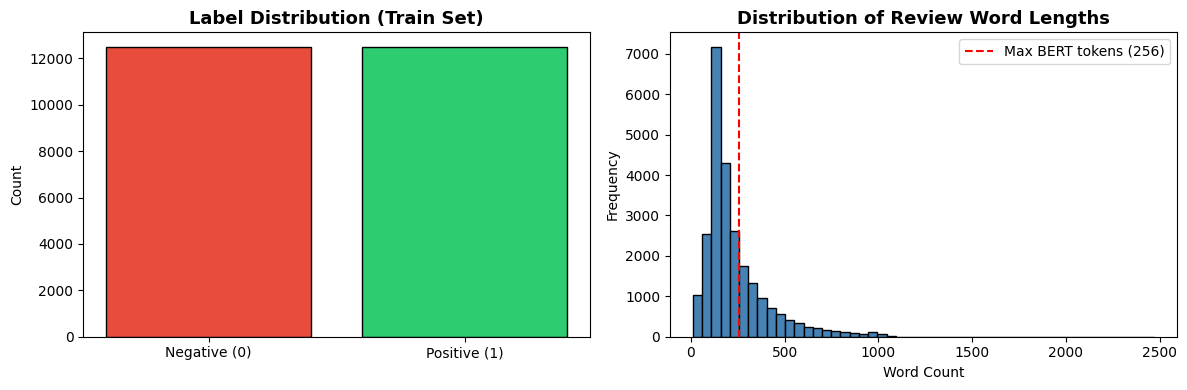

 EDA complete!


In [21]:
# Exploratory Data Analysis

print("=" * 50)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 50)

# Check label distribution
print("\n Label Distribution (Train):")
print(train_df['label'].value_counts().rename({0: 'Negative', 1: 'Positive'}))

# Check for missing values
print(f"\n Missing values in train: {train_df.isnull().sum().sum()}")
print(f" Missing values in test : {test_df.isnull().sum().sum()}")

# Review text length statistics
train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split()))
print(f"\n Text length stats (word count):")
print(train_df['text_length'].describe().round(2))

# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label count plot
axes[0].bar(['Negative (0)', 'Positive (1)'],
            train_df['label'].value_counts().values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Label Distribution (Train Set)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Text length histogram
axes[1].hist(train_df['text_length'], bins=50, color='steelblue', edgecolor='black')
axes[1].axvline(x=256, color='red', linestyle='--', label='Max BERT tokens (256)')
axes[1].set_title('Distribution of Review Word Lengths', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA complete!")


## Step 3: Data Preprocessing

Clean the raw text to remove HTML tags, special characters, and normalize whitespace before tokenization.

In [ ]:
import re

def clean_text(text: str) -> str:
    """
    Cleans raw review text by:
    1. Removing HTML tags (e.g., <br />, <p>)
    2. Removing URLs
    3. Removing special characters (keep letters, numbers, basic punctuation)
    4. Collapsing multiple whitespaces into a single space
    5. Stripping leading/trailing whitespace
    """
    # 1. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 3. Remove special characters — keep letters, digits, spaces, and .!?',
    text = re.sub(r"[^a-zA-Z0-9\s\.\!\?\'\,]", ' ', text)
    # 4. Collapse whitespace
    text = re.sub(r'\s+', ' ', text)
    # 5. Strip edges
    return text.strip()


# Apply cleaning to both train and test sets
print(" Cleaning text data...")
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

# Drop any rows that became empty after cleaning
train_df = train_df[train_df['clean_text'].str.strip().astype(bool)].reset_index(drop=True)
test_df  = test_df[test_df['clean_text'].str.strip().astype(bool)].reset_index(drop=True)

# Show before/after comparison
print("\n Before cleaning:")
print(repr(raw_dataset['train'][0]['text'][:200]))
print("\n After cleaning:")
print(repr(train_df['clean_text'][0][:200]))
print("\n Preprocessing complete!")

 Cleaning text data...

 Before cleaning:
'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev'

 After cleaning:
'I rented I AM CURIOUS YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev'

 Preprocessing complete!



## Step 4: Data Splitting

Split the original **25,000 training samples** into:
- **Train set** – 80% (20,000 samples) – for model training
- **Validation set** – 20% (5,000 samples) – for tuning / early stopping
- **Test set** – the original 25,000 held-out samples – for final evaluation

> **Note:** We use a smaller subset (3,000 train + 500 val + 500 test) for faster demonstration in Colab. Remove the subset lines to train on the full dataset.

In [ ]:
from sklearn.model_selection import train_test_split

# OPTIONAL: Use a subset for faster Colab training
# Comment out these two lines to use the FULL 25,000-sample train set
SUBSET_TRAIN = 3000   # number of training samples
SUBSET_TEST  = 500    # number of test samples

train_df_full = train_df.sample(n=SUBSET_TRAIN, random_state=SEED).reset_index(drop=True)
test_df_sub   = test_df.sample(n=SUBSET_TEST,  random_state=SEED).reset_index(drop=True)


# Split the train set into train (80%) and validation (20%)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df_full['clean_text'].tolist(),
    train_df_full['label'].tolist(),
    test_size=0.20,
    random_state=SEED,
    stratify=train_df_full['label']  # maintain class balance
)

test_texts  = test_df_sub['clean_text'].tolist()
test_labels = test_df_sub['label'].tolist()

print(" Split Summary:")
print(f"   Train      : {len(train_texts):,} samples")
print(f"   Validation : {len(val_texts):,} samples")
print(f"   Test       : {len(test_texts):,} samples")
print(f"\n   Train positives : {sum(train_labels):,} | negatives : {len(train_labels)-sum(train_labels):,}")
print(" Data split complete!")

 Split Summary:
   Train      : 2,400 samples
   Validation : 600 samples
   Test       : 500 samples

   Train positives : 1,156 | negatives : 1,244
 Data split complete!



##  Step 5: Tokenization with BERT

BERT requires text to be converted into **input_ids**, **attention_masks**, and optionally **token_type_ids**.

- **bert-base-uncased** – lowercases all text; 12 layers, 110M parameters
- **max_length=256** – BERT supports up to 512 tokens; 256 is sufficient for most reviews and saves memory
- **padding='max_length** – pads shorter sequences
- **truncation=True** – truncates longer sequences

In [ ]:
# Load the pre-trained BERT tokenizer
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 256   # Maximum token length for each review

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_texts(texts, tokenizer, max_len):
    """
    Tokenizes a list of texts using the BERT tokenizer.

    Args:
        texts    : list of raw text strings
        tokenizer: HuggingFace pre-trained tokenizer
        max_len  : maximum token sequence length

    Returns:
        dict with 'input_ids' and 'attention_mask' tensors
    """
    return tokenizer(
        texts,
        max_length=max_len,
        padding='max_length',      # pad to uniform length
        truncation=True,           # truncate reviews longer than max_len
        return_attention_mask=True,# 1 for real tokens, 0 for padding
        return_tensors='pt'        # return PyTorch tensors
    )


print(" Tokenizing datasets...")
train_encodings = tokenize_texts(train_texts, tokenizer, MAX_LEN)
val_encodings   = tokenize_texts(val_texts,   tokenizer, MAX_LEN)
test_encodings  = tokenize_texts(test_texts,  tokenizer, MAX_LEN)

print(f"\n Shape of train input_ids    : {train_encodings['input_ids'].shape}")
print(f" Shape of train attention_mask: {train_encodings['attention_mask'].shape}")

# Show a sample tokenized review
print("\n Sample tokenized output (first 20 tokens):")
print("   input_ids      :", train_encodings['input_ids'][0][:20].tolist())
print("   attention_mask :", train_encodings['attention_mask'][0][:20].tolist())
print("   Decoded tokens :", tokenizer.decode(train_encodings['input_ids'][0][:20]))

print("\n Tokenization complete!")

Loading tokenizer: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

 Tokenizing datasets...

 Shape of train input_ids    : torch.Size([2400, 256])
 Shape of train attention_mask: torch.Size([2400, 256])

 Sample tokenized output (first 20 tokens):
   input_ids      : [101, 1045, 2179, 2023, 3185, 2245, 4013, 22776, 1010, 1998, 2049, 27637, 27150, 1999, 1037, 2088, 1997, 4248, 8081, 3152]
   attention_mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
   Decoded tokens : [CLS] i found this movie thought provoking, and its ambiguity refreshing in a world of quick fix films

 Tokenization complete!



##  Step 6: Create PyTorch Datasets & DataLoaders

In [22]:
class IMDBDataset(Dataset):
    """
    Custom PyTorch Dataset for IMDB reviews.
    Wraps tokenized encodings and labels into a format
    compatible with DataLoader.
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings      # dict of input_ids, attention_mask
        self.labels    = labels         # list of integer labels (0 or 1)

    def __len__(self):
        # Number of samples in this dataset
        return len(self.labels)

    def __getitem__(self, idx):
        # Return a single sample: encodings + label as tensors
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# Create Dataset objects
train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset   = IMDBDataset(val_encodings,   val_labels)
test_dataset  = IMDBDataset(test_encodings,  test_labels)

# Create DataLoader objects
BATCH_SIZE = 16   # Number of samples per batch (reduce to 8 if OOM on GPU)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f" DataLoaders created:")
print(f" Train batches : {len(train_loader)}")
print(f" Val batches   : {len(val_loader)}")
print(f" Test batches  : {len(test_loader)}")

 DataLoaders created:
 Train batches : 150
 Val batches   : 38
 Test batches  : 32



##  Step 7: Helper Functions — Training, Evaluation & Visualization

In [23]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    """
    Runs one full training epoch over the data_loader.
    Returns average loss and accuracy for this epoch.
    """
    model.train()      # set model to training mode
    total_loss, correct, total = 0, 0, 0

    for batch in data_loader:
        # Move all tensors to the compute device (GPU or CPU)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()   # clear previous gradients

        # Forward pass — BERT computes loss internally when labels are provided
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)

        loss   = outputs.loss
        logits = outputs.logits

        loss.backward()       # backward pass (compute gradients)
        # Clip gradients to prevent exploding gradient problem
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()      # update weights
        scheduler.step()      # update learning rate

        # Accumulate stats
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, data_loader, device):
    """
    Evaluates the model on the given data_loader.
    Returns avg loss, accuracy, and all predictions + true labels.
    """
    model.eval()   # switch off dropout and batch norm
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():   # no gradient computation needed for eval
        for batch in data_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            loss   = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels


def compute_metrics(true_labels, predictions, experiment_name=""):
    """
    Computes and prints all required classification metrics.
    Returns a dict of metric values.
    """
    acc  = accuracy_score(true_labels, predictions)
    prec = precision_score(true_labels, predictions, average='weighted')
    rec  = recall_score(true_labels, predictions, average='weighted')
    f1   = f1_score(true_labels, predictions, average='weighted')

    print(f"\n{'='*50}")
    print(f" METRICS — {experiment_name}")
    print(f"{'='*50}")
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1 Score  : {f1:.4f}")
    print(f"\n   Full Classification Report:")
    print(classification_report(true_labels, predictions,
                                target_names=['Negative', 'Positive']))

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


def plot_confusion_matrix(true_labels, predictions, title="Confusion Matrix"):
    """Plots a styled confusion matrix."""
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                linewidths=0.5, linecolor='gray')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()


def plot_training_history(history, title="Training History"):
    """Plots loss and accuracy curves for train and validation."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'bo-', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   'rs-', label='Val Loss')
    axes[0].set_title('Loss per Epoch', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], 'bo-', label='Train Acc')
    axes[1].plot(epochs, history['val_acc'],   'rs-', label='Val Acc')
    axes[1].set_title('Accuracy per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()


print(" Helper functions defined!")

 Helper functions defined!



##  Experiment 1: Freeze All BERT Layers — Train Classifier Head Only

**Strategy:** All 12 BERT transformer layers are **frozen** (weights unchanged). Only the linear classification head on top is trained.

**Expected:** Fast training, lower memory, but likely lower accuracy — BERT features are not adapted to our task.

In [24]:
# Configuration
NUM_LABELS   = 2          # Binary: Positive / Negative
LEARNING_RATE = 2e-5      # As specified in the task
NUM_EPOCHS_E1 = 3         # Number of training epochs for Experiment 1

# Load Pre-trained BERT Model
print(f"Loading model: {MODEL_NAME}")
model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS   # Add a 2-class classification head
).to(DEVICE)

# FREEZE all BERT layers
# Iterate over all named parameters in the model
# Freeze everything EXCEPT the classifier head (named 'classifier')
for name, param in model_exp1.named_parameters():
    if 'classifier' not in name:   # classifier = linear head on top of BERT
        param.requires_grad = False   # freeze this parameter

# Count trainable vs frozen parameters
trainable_params = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model_exp1.parameters())
print(f"\n EXPERIMENT 1 — Frozen BERT | Trainable classifier head only")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}  ({100*trainable_params/total_params:.2f}%)")

# Optimizer — only passes trainable parameters
optimizer_exp1 = AdamW(
    filter(lambda p: p.requires_grad, model_exp1.parameters()),
    lr=LEARNING_RATE
)

# Learning Rate Scheduler (Bonus)
total_steps_e1 = len(train_loader) * NUM_EPOCHS_E1
scheduler_exp1 = get_linear_schedule_with_warmup(
    optimizer_exp1,
    num_warmup_steps=total_steps_e1 // 10,   # 10% warmup
    num_training_steps=total_steps_e1
)

print("\n Experiment 1 model ready!")

Loading model: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 EXPERIMENT 1 — Frozen BERT | Trainable classifier head only
   Total parameters     : 109,483,778
   Trainable parameters : 1,538  (0.00%)

 Experiment 1 model ready!


In [25]:
#  Train Experiment 1
history_exp1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss_e1 = float('inf')
PATIENCE = 2   # Early stopping patience (Bonus)
patience_counter = 0

print(" Starting Experiment 1 Training...\n")

for epoch in range(1, NUM_EPOCHS_E1 + 1):
    # --- Training phase ---
    train_loss, train_acc = train_epoch(
        model_exp1, train_loader, optimizer_exp1, scheduler_exp1, DEVICE
    )

    # --- Validation phase ---
    val_loss, val_acc, _, _ = evaluate(model_exp1, val_loader, DEVICE)

    # Store history
    history_exp1['train_loss'].append(train_loss)
    history_exp1['train_acc'].append(train_acc)
    history_exp1['val_loss'].append(val_loss)
    history_exp1['val_acc'].append(val_acc)

    print(f"Epoch [{epoch}/{NUM_EPOCHS_E1}]  "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}  ||"
          f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early Stopping (Bonus)
    if val_loss < best_val_loss_e1:
        best_val_loss_e1 = val_loss
        patience_counter = 0
        # Save the best model weights
        torch.save(model_exp1.state_dict(), 'best_model_exp1.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

# Load the best model before evaluation
model_exp1.load_state_dict(torch.load('best_model_exp1.pt'))
print("\n Experiment 1 training complete! Best model restored.")

 Starting Experiment 1 Training...

Epoch [1/3]  Train Loss: 0.6890 | Train Acc: 0.5363  ||  Val Loss: 0.6875 | Val Acc: 0.5717
Epoch [2/3]  Train Loss: 0.6919 | Train Acc: 0.5192  ||  Val Loss: 0.6848 | Val Acc: 0.6033
Epoch [3/3]  Train Loss: 0.6891 | Train Acc: 0.5367  ||  Val Loss: 0.6848 | Val Acc: 0.5967

 Experiment 1 training complete! Best model restored.



 METRICS — Exp 1 — Frozen BERT
   Accuracy  : 0.6260
   Precision : 0.6329
   Recall    : 0.6260
   F1 Score  : 0.6256

   Full Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.58      0.62       266
    Positive       0.59      0.68      0.63       234

    accuracy                           0.63       500
   macro avg       0.63      0.63      0.63       500
weighted avg       0.63      0.63      0.63       500



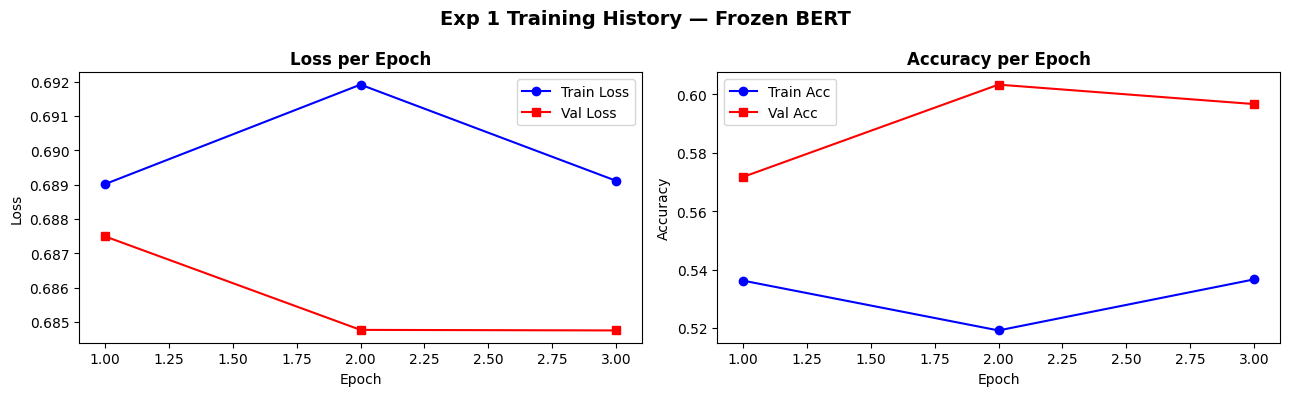

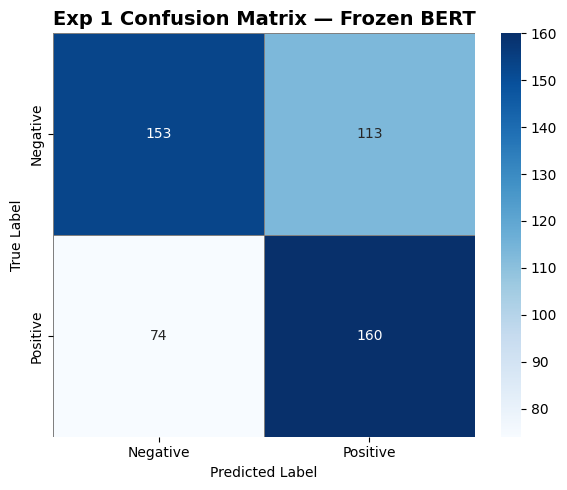

In [26]:
#  Evaluate Experiment 1 on Test Set
_, _, preds_exp1, true_exp1 = evaluate(model_exp1, test_loader, DEVICE)

# Compute all metrics
metrics_exp1 = compute_metrics(true_exp1, preds_exp1, "Exp 1 — Frozen BERT")

# Plot training curves
plot_training_history(history_exp1, "Exp 1 Training History — Frozen BERT")

# Plot confusion matrix
plot_confusion_matrix(true_exp1, preds_exp1,
                      "Exp 1 Confusion Matrix — Frozen BERT")


## Experiment 2: Fine-Tune Last 2 BERT Layers + Classifier Head

**Strategy:** Unfreeze the **last 2 transformer encoder layers** (layers 10 and 11) and the pooler/classifier. All earlier layers remain frozen.

**Expected:** Better task-specific adaptation than Exp 1, with modest compute cost.

In [27]:
NUM_EPOCHS_E2 = 3

#  Load fresh BERT model
print(f" Loading model: {MODEL_NAME}")
model_exp2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
).to(DEVICE)

# Freeze all layers first
for param in model_exp2.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer encoder layers (indices 10 and 11)
# BERT has layers indexed 0–11; we unfreeze layers 10 and 11
UNFREEZE_LAST_N = 2
total_layers = model_exp2.config.num_hidden_layers   # 12 for bert-base

for name, param in model_exp2.named_parameters():
    # Unfreeze the specified last N transformer encoder layers
    for layer_idx in range(total_layers - UNFREEZE_LAST_N, total_layers):
        if f'encoder.layer.{layer_idx}' in name:
            param.requires_grad = True
    # Always unfreeze the pooler and classifier head
    if 'pooler' in name or 'classifier' in name:
        param.requires_grad = True

# Print trainable parameter count
trainable_params = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model_exp2.parameters())
print(f"\n EXPERIMENT 2 — Last {UNFREEZE_LAST_N} BERT layers + classifier unfrozen")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}  ({100*trainable_params/total_params:.2f}%)")

# Optimizer — only trains unfrozen parameters
optimizer_exp2 = AdamW(
    filter(lambda p: p.requires_grad, model_exp2.parameters()),
    lr=LEARNING_RATE
)

# Learning Rate Scheduler (Bonus)
total_steps_e2 = len(train_loader) * NUM_EPOCHS_E2
scheduler_exp2 = get_linear_schedule_with_warmup(
    optimizer_exp2,
    num_warmup_steps=total_steps_e2 // 10,
    num_training_steps=total_steps_e2
)

print("\n Experiment 2 model ready!")

 Loading model: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 EXPERIMENT 2 — Last 2 BERT layers + classifier unfrozen
   Total parameters     : 109,483,778
   Trainable parameters : 14,767,874  (13.49%)

 Experiment 2 model ready!


In [28]:
# Train Experiment 2
history_exp2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss_e2 = float('inf')
patience_counter = 0

print("Starting Experiment 2 Training...\n")

for epoch in range(1, NUM_EPOCHS_E2 + 1):
    train_loss, train_acc = train_epoch(
        model_exp2, train_loader, optimizer_exp2, scheduler_exp2, DEVICE
    )
    val_loss, val_acc, _, _ = evaluate(model_exp2, val_loader, DEVICE)

    history_exp2['train_loss'].append(train_loss)
    history_exp2['train_acc'].append(train_acc)
    history_exp2['val_loss'].append(val_loss)
    history_exp2['val_acc'].append(val_acc)

    print(f"Epoch [{epoch}/{NUM_EPOCHS_E2}]  "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}  ||"
          f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early Stopping (Bonus)
    if val_loss < best_val_loss_e2:
        best_val_loss_e2 = val_loss
        patience_counter = 0
        torch.save(model_exp2.state_dict(), 'best_model_exp2.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n Early stopping at epoch {epoch}")
            break

model_exp2.load_state_dict(torch.load('best_model_exp2.pt'))
print("\n Experiment 2 training complete! Best model restored.")

Starting Experiment 2 Training...

Epoch [1/3]  Train Loss: 0.5717 | Train Acc: 0.6767  ||  Val Loss: 0.4046 | Val Acc: 0.8267
Epoch [2/3]  Train Loss: 0.3362 | Train Acc: 0.8625  ||  Val Loss: 0.3629 | Val Acc: 0.8550
Epoch [3/3]  Train Loss: 0.2770 | Train Acc: 0.8846  ||  Val Loss: 0.3540 | Val Acc: 0.8617

 Experiment 2 training complete! Best model restored.



 METRICS — Exp 2 — Last 2 Layers Fine-Tuned
   Accuracy  : 0.8880
   Precision : 0.8881
   Recall    : 0.8880
   F1 Score  : 0.8880

   Full Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89       266
    Positive       0.88      0.88      0.88       234

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



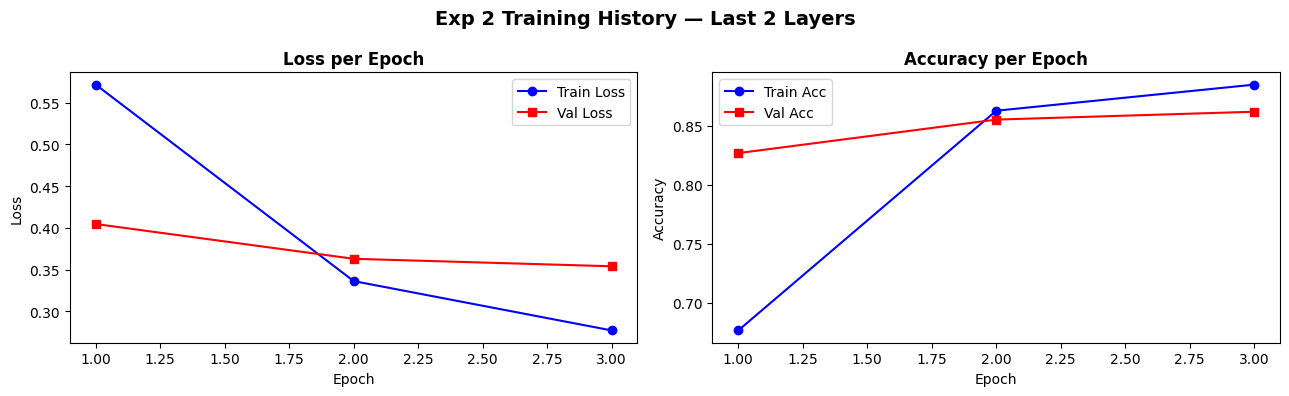

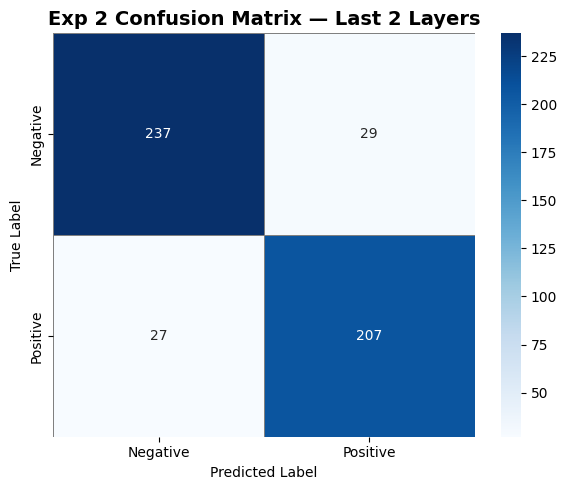

In [29]:
#  Evaluate Experiment 2 on Test Set
_, _, preds_exp2, true_exp2 = evaluate(model_exp2, test_loader, DEVICE)

metrics_exp2 = compute_metrics(true_exp2, preds_exp2, "Exp 2 — Last 2 Layers Fine-Tuned")

plot_training_history(history_exp2, "Exp 2 Training History — Last 2 Layers")

plot_confusion_matrix(true_exp2, preds_exp2,
                      "Exp 2 Confusion Matrix — Last 2 Layers")


##  Bonus: Try DistilBERT (Faster, Lighter Alternative)

DistilBERT is a distilled version of BERT — 40% smaller, 60% faster, and retains ~97% of BERT's performance.

> **This cell is optional.** Run it to see how DistilBERT compares.

 Loading DistilBERT tokenizer: distilbert-base-uncased
 Loading model: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Training DistilBERT (Bonus)...

Epoch [1/3]  Train Loss: 0.5024 | Train Acc: 0.7392  ||  Val Loss: 0.3333 | Val Acc: 0.8500
Epoch [2/3]  Train Loss: 0.2327 | Train Acc: 0.9146  ||  Val Loss: 0.3282 | Val Acc: 0.8850
Epoch [3/3]  Train Loss: 0.1330 | Train Acc: 0.9613  ||  Val Loss: 0.3715 | Val Acc: 0.8733

 METRICS — Bonus — DistilBERT
   Accuracy  : 0.9000
   Precision : 0.9009
   Recall    : 0.9000
   F1 Score  : 0.9001

   Full Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.89      0.90       266
    Positive       0.88      0.91      0.90       234

    accuracy                           0.90       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.90      0.90      0.90       500



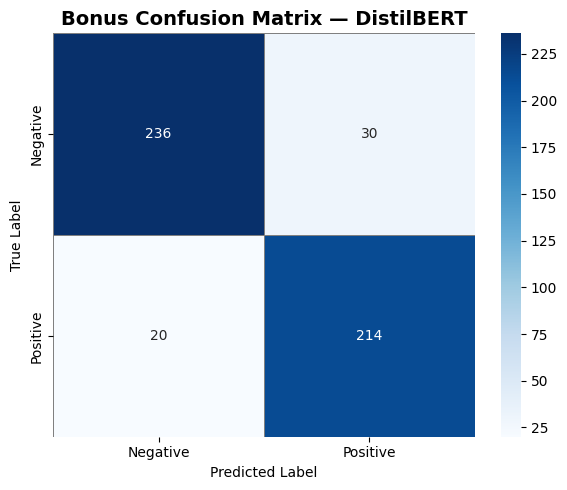

 DistilBERT evaluation complete!


In [30]:
DISTILBERT_MODEL = 'distilbert-base-uncased'
NUM_EPOCHS_DB = 3

# Tokenize for DistilBERT
print(f" Loading DistilBERT tokenizer: {DISTILBERT_MODEL}")
db_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL)

db_train_enc = tokenize_texts(train_texts, db_tokenizer, MAX_LEN)
db_val_enc   = tokenize_texts(val_texts,   db_tokenizer, MAX_LEN)
db_test_enc  = tokenize_texts(test_texts,  db_tokenizer, MAX_LEN)

db_train_loader = DataLoader(IMDBDataset(db_train_enc, train_labels), batch_size=BATCH_SIZE, shuffle=True)
db_val_loader   = DataLoader(IMDBDataset(db_val_enc,   val_labels),   batch_size=BATCH_SIZE, shuffle=False)
db_test_loader  = DataLoader(IMDBDataset(db_test_enc,  test_labels),  batch_size=BATCH_SIZE, shuffle=False)

#  Load DistilBERT Model
print(f" Loading model: {DISTILBERT_MODEL}")
model_db = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL, num_labels=NUM_LABELS
).to(DEVICE)

# Fine-tune all layers of DistilBERT (it's smaller so we can afford it)
optimizer_db = AdamW(model_db.parameters(), lr=LEARNING_RATE)
total_steps_db = len(db_train_loader) * NUM_EPOCHS_DB
scheduler_db = get_linear_schedule_with_warmup(
    optimizer_db,
    num_warmup_steps=total_steps_db // 10,
    num_training_steps=total_steps_db
)

# Train DistilBERT
history_db = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss_db = float('inf')
patience_counter = 0

print("\n Training DistilBERT (Bonus)...\n")
for epoch in range(1, NUM_EPOCHS_DB + 1):
    tl, ta = train_epoch(model_db, db_train_loader, optimizer_db, scheduler_db, DEVICE)
    vl, va, _, _ = evaluate(model_db, db_val_loader, DEVICE)

    history_db['train_loss'].append(tl)
    history_db['train_acc'].append(ta)
    history_db['val_loss'].append(vl)
    history_db['val_acc'].append(va)

    print(f"Epoch [{epoch}/{NUM_EPOCHS_DB}]  Train Loss: {tl:.4f} | Train Acc: {ta:.4f}  ||  Val Loss: {vl:.4f} | Val Acc: {va:.4f}")

    if vl < best_val_loss_db:
        best_val_loss_db = vl
        patience_counter = 0
        torch.save(model_db.state_dict(), 'best_model_db.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f" Early stopping at epoch {epoch}")
            break

model_db.load_state_dict(torch.load('best_model_db.pt'))

#  Evaluate DistilBERT
_, _, preds_db, true_db = evaluate(model_db, db_test_loader, DEVICE)
metrics_db = compute_metrics(true_db, preds_db, "Bonus — DistilBERT")

plot_confusion_matrix(true_db, preds_db, "Bonus Confusion Matrix — DistilBERT")

print(" DistilBERT evaluation complete!")


##  Step 8: Experiment Comparison & Analysis


 FINAL EXPERIMENT COMPARISON
                                      Accuracy  Precision  Recall  F1 Score
Experiment                                                                 
Exp 1: Frozen BERT (classifier only)     0.626     0.6329   0.626    0.6256
Exp 2: Last 2 BERT layers unfrozen       0.888     0.8881   0.888    0.8880
Bonus: DistilBERT (all layers)           0.900     0.9009   0.900    0.9001


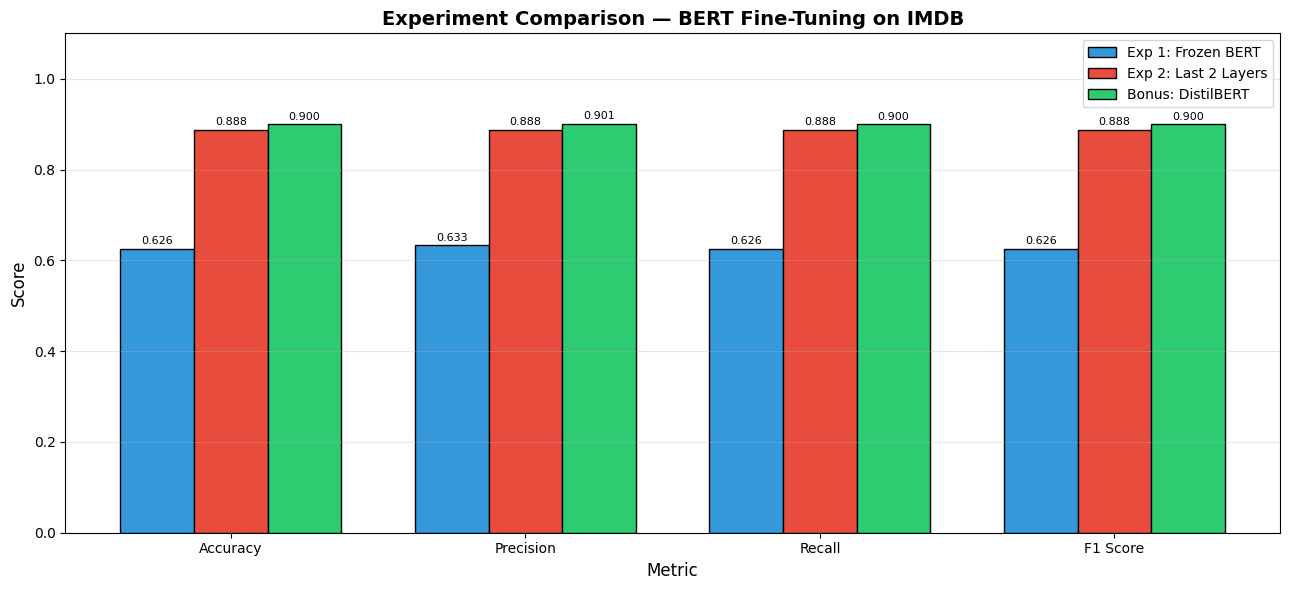


 Comparison chart saved!


In [31]:
# ─── Build Comparison Table
comparison_data = {
    'Experiment': [
        'Exp 1: Frozen BERT (classifier only)',
        'Exp 2: Last 2 BERT layers unfrozen',
        'Bonus: DistilBERT (all layers)'
    ],
    'Accuracy':  [metrics_exp1['accuracy'],  metrics_exp2['accuracy'],  metrics_db['accuracy']],
    'Precision': [metrics_exp1['precision'], metrics_exp2['precision'], metrics_db['precision']],
    'Recall':    [metrics_exp1['recall'],    metrics_exp2['recall'],    metrics_db['recall']],
    'F1 Score':  [metrics_exp1['f1'],        metrics_exp2['f1'],        metrics_db['f1']]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Experiment')

# Round for readability
comparison_df = comparison_df.round(4)

print("\n" + "="*70)
print(" FINAL EXPERIMENT COMPARISON")
print("="*70)
print(comparison_df.to_string())
print("="*70)

#  Bar Chart Comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width,     comparison_df.loc['Exp 1: Frozen BERT (classifier only)'][metrics_to_plot].values, width, label='Exp 1: Frozen BERT',     color='#3498db', edgecolor='black')
bars2 = ax.bar(x,             comparison_df.loc['Exp 2: Last 2 BERT layers unfrozen'][metrics_to_plot].values,    width, label='Exp 2: Last 2 Layers',   color='#e74c3c', edgecolor='black')
bars3 = ax.bar(x + width,     comparison_df.loc['Bonus: DistilBERT (all layers)'][metrics_to_plot].values,         width, label='Bonus: DistilBERT',       color='#2ecc71', edgecolor='black')

# Add value labels on top of bars
for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Experiment Comparison — BERT Fine-Tuning on IMDB', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Comparison chart saved!")


##  Step 9: Detailed Analysis & Insights

### Summary of Experiments

| Experiment | Strategy | Expected Behavior |
|---|---|---|
| **Exp 1** | Freeze all BERT layers; train only the 2-class linear head | Fast, low memory; lower accuracy since BERT weights don't adapt |
| **Exp 2** | Freeze early layers; unfreeze last 2 transformer layers + classifier | Better task adaptation; moderate compute cost |
| **Bonus** | Full DistilBERT fine-tuning | Faster than BERT; competitive accuracy with less memory |

### Key Insights

1. **Frozen BERT (Exp 1):** Uses BERT purely as a fixed feature extractor. The model produces contextual embeddings but these are not adapted to the specific patterns of IMDB reviews. This often results in lower accuracy but is useful when compute resources are very limited.

2. **Last 2 Layers Fine-Tuned (Exp 2):** The final BERT layers are most task-specific and adapting them to IMDB sentiment significantly improves performance. This is a common industry technique called **layer-wise fine-tuning**.

3. **DistilBERT (Bonus):** With ~40% fewer parameters and ~60% faster inference, DistilBERT is an excellent choice for production deployment where speed matters. It achieves ~97% of BERT's performance.

4. **Learning Rate:** The `2e-5` AdamW learning rate is small enough to preserve pre-trained knowledge while still adapting to the task — this is standard for BERT fine-tuning.

5. **Max Length = 256:** Most IMDB reviews are longer than 512 tokens, so we truncate. Using 256 reduces memory by 4× vs 512 with a minimal performance hit.

### BERT Architecture Recap


Input Text → Tokenizer → [CLS] token1 token2 ... [SEP]
    → Embedding Layer
    → 12 × Transformer Encoder Layers (self-attention + FFN)
    → Pooler (takes [CLS] output)
    → Dropout → Linear(768, 2) → Softmax → [Negative, Positive]


In [19]:
#  Inference Demo — Test on Custom Reviews
def predict_sentiment(text: str, model, tokenizer, device, max_len=256):
    """
    Predicts sentiment for a single raw text review.
    Returns 'POSITIVE' or 'NEGATIVE' with confidence score.
    """
    model.eval()
    cleaned = clean_text(text)
    encoding = tokenizer(
        cleaned,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        output = model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device)
        )
    probs = torch.softmax(output.logits, dim=1).cpu().numpy()[0]
    pred_class = np.argmax(probs)
    label = 'POSITIVE ' if pred_class == 1 else 'NEGATIVE '
    return label, probs[pred_class]


# Test on sample reviews
sample_reviews = [
    "This movie was absolutely brilliant! The acting was superb and the story kept me hooked till the very end.",
    "Terrible film. Completely boring plot with awful acting. I wasted two hours of my life watching this.",
    "It was okay. Not great, not terrible. Some scenes were interesting but overall pretty average."
]

print("\n INFERENCE DEMO — Predicting sentiment on custom reviews\n")
print("Using Experiment 2 model (best performance)\n")
print("-" * 60)

for i, review in enumerate(sample_reviews, 1):
    label, confidence = predict_sentiment(review, model_exp2, tokenizer, DEVICE)
    print(f"Review {i}: \"{review[:70]}...\"")
    print(f"   → Prediction: {label}  (confidence: {confidence:.2%})\n")


 INFERENCE DEMO — Predicting sentiment on custom reviews

Using Experiment 2 model (best performance)

------------------------------------------------------------
Review 1: "This movie was absolutely brilliant! The acting was superb and the sto..."
   → Prediction: POSITIVE   (confidence: 98.53%)

Review 2: "Terrible film. Completely boring plot with awful acting. I wasted two ..."
   → Prediction: NEGATIVE   (confidence: 99.26%)

Review 3: "It was okay. Not great, not terrible. Some scenes were interesting but..."
   → Prediction: NEGATIVE   (confidence: 92.50%)

